In [49]:
from dataclasses import dataclass, field
import matplotlib.pyplot as plt
import numpy as np

@dataclass(slots=True)
class EnsembleKalmanFilter:
    """
    A class representing an Ensemble Kalman Filter (EnKF) for data assimilation.
    """
    TransitionEquation: callable
    ObservationEquation: callable
    Q: np.ndarray
    R: np.ndarray
    seed = None

    def __post_init__(self):
        if self.seed is None:
            self.rng = np.random.default_rng()
        else:
            self.rng = np.random.default_rng(self.seed)

    def predict(self, states: np.ndarray) -> np.ndarray:
        """
        Predict the next state of the ensemble using the transition equation and process noise.
        """
        predicted_states = self.TransitionEquation(states)
        predicted_states += self.rng.multivariate_normal(mean=np.zeros(self.n_states), cov=self.Q, size=self.EnsembleSize).T
        return predicted_states
    
    def update(self, predicted_states: np.ndarray, observation: np.ndarray) -> np.ndarray:
        """
        Update the ensemble states using the observation and the Kalman gain.
        """
        predicted_observations = self.ObservationEquation(predicted_states)
        predicted_observations += self.rng.multivariate_normal(mean=np.zeros(self.n_obs), cov=self.R, size=self.EnsembleSize).T

        U = (predicted_states - np.mean(predicted_states, axis=1, keepdims=True))/ np.sqrt(self.EnsembleSize - 1)
        V = (predicted_observations - np.mean(predicted_observations, axis=1, keepdims=True))/ np.sqrt(self.EnsembleSize - 1)

        K = U @ np.linalg.pinv(V)

        updated_states = predicted_states + K @ (observation - predicted_observations)

        innovation = observation - np.mean(predicted_observations, axis=1, keepdims=True)
        whitened_innovation = np.linalg.solve(np.linalg.cholesky(V @ V.T), innovation)

        self.result.append(updated_states, np.mean(predicted_observations, axis=1), innovation, whitened_innovation)

        return updated_states

    def run(self, initial_ensemble: np.ndarray, times: np.ndarray, observations: np.ndarray) -> FilterResult:
        """
        Run the Ensemble Kalman Filter over a sequence of observations.
        """
        states = self.initialize(initial_ensemble)

        self.result = FilterResult()

        for t, obsT in zip(times, observations.T):
            obs = obsT.T
            predicted_states = self.predict(states)
            states = self.update(predicted_states, obs)

        return self.result
    
    def initialize(self, initial_ensemble: np.ndarray) -> np.ndarray:
        self.n_states = initial_ensemble.shape[0]
        self.EnsembleSize = initial_ensemble.shape[1]
        return initial_ensemble

        
@dataclass(slots=True)
class FilterResult:
    """Container for filter history and diagnostics."""
    ensembles: list[np.ndarray] = field(default_factory=list)
    predicted_observations: list[np.ndarray] = field(default_factory=list)
    innovations: list[np.ndarray] = field(default_factory=list)
    whitened_innovations: list[np.ndarray] = field(default_factory=list)

    def append(self, ensemble: np.ndarray, predicted_observation: np.ndarray, innovation: np.ndarray, whitened_innovation: np.ndarray, ) -> None:
        self.ensembles.append(np.asarray(ensemble, dtype=float))
        self.predicted_observations.append(np.asarray(predicted_observation, dtype=float))
        self.innovations.append(np.asarray(innovation, dtype=float))
        self.whitened_innovations.append(np.asarray(whitened_innovation, dtype=float))

    def plot_ensembles(self) -> plt.Figure:
        fig, ax = plt.subplots()
        for ens in self.ensembles:
            ax.plot(ens.T, color='blue', alpha=0.1)
        return fig

In [17]:
@dataclass(slots=True)
class LorenzParameters():
    sigma: float = 10.0
    rho: float = 28.0
    beta: float = 8.0 / 3.0

def LorenzTransition(states: np.ndarray, lorenz_params: LorenzParameters, dt: float = 0.01) -> np.ndarray:
    """
    Transition function for the Lorenz system.
    Vectorized to operate on an ensemble of states.
    Parameters:
    - states: A 2D array of shape (3, EnsembleSize) representing the ensemble of states.
    - lorenz_params: An object containing the Lorenz system parameters (sigma, rho, beta).
    - dt: The time step for the transition.
    Returns:
    - A 2D array of shape (3, EnsembleSize) representing the updated states
    """
    par = lorenz_params
    dxdt = par.sigma * (states[1] - states[0])
    dydt = states[0] * (par.rho - states[2]) - states[1]
    dzdt = states[0] * states[1] - par.beta * states[2]
    return states + np.array([dxdt, dydt, dzdt]) * dt

def LorenzObservation(states: np.ndarray) -> np.ndarray:
    """
    Observation function for the Lorenz system.
    Vectorized to operate on an ensemble of states, observing only the x component.
    Parameters:
    - states: A 2D array of shape (3, EnsembleSize) representing the ensemble of states.
    Returns:
    - A 2D array of shape (2, EnsembleSize) representing the observed values (x and y components).
    """
    return states[0:2, :]

Iteration 1
Iteration 21
Iteration 41
Iteration 61
Iteration 81
Iteration 101
Iteration 121
Iteration 141
Iteration 161
Iteration 181
Iteration 201
Iteration 221
Iteration 241
Iteration 261
Iteration 281
Iteration 301
Iteration 321
Iteration 341
Iteration 361
Iteration 381
Iteration 401
Iteration 421
Iteration 441
Iteration 461
Iteration 481
Iteration 501
Iteration 521
Iteration 541
Iteration 561
Iteration 581


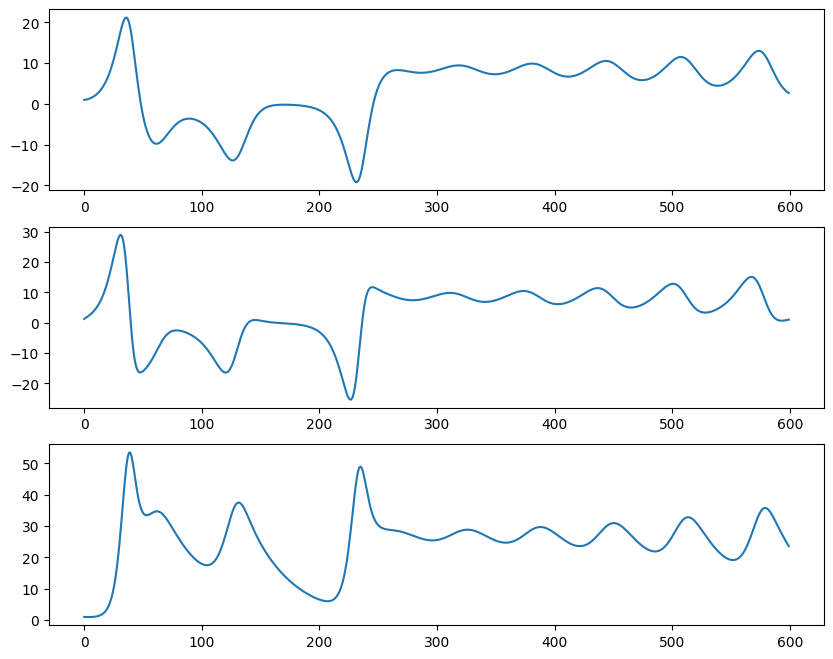

In [23]:
DT = 0.01
times = np.arange(0, 6, DT)
sim_state0 = np.array([[1.0], [1.0], [1.0]])
lorenz_params = LorenzParameters()

sim_obs = np.empty((2, len(times)))
state  = sim_state0
for i, t in enumerate(times):
    state = LorenzTransition(state, lorenz_params, dt=DT)
    sim_obs[:, i] = LorenzObservation(state).flatten()

enkf = EnsembleKalmanFilter(TransitionEquation=lambda states: LorenzTransition(states, lorenz_params, dt=DT),
                           ObservationEquation=LorenzObservation,
                           Q=np.diag([0.1, 0.1, 0.1]),
                           R=np.diag([0.1, 0.1]))

result = enkf.run(initial_ensemble=sim_state0, times=times, observations=sim_obs)